# Markdown Title

In [ ]:
# Importing necessary modules for analysis
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [8]:
# Loading csv file into data frame
mcdavid_df = pd.read_csv('../data/mcdavid_game_log.csv')
mcdavid_df.head(10)

,date,opponent,goals,assists,points,plus_minus,SOG,TOI,result,team_score,opp_score,game_number,game_context,season
0,2024-06-08,FLA,0,0,0,-2,6.0,25:19,L,0,3,1.0,stanley_cup_finals,2023-24
1,2024-06-10,FLA,0,1,1,1,3.0,25:59,L,1,4,2.0,stanley_cup_finals,2023-24
2,2024-06-13,FLA,0,2,2,1,5.0,25:14,L,3,4,3.0,stanley_cup_finals,2023-24
3,2024-06-15,FLA,1,3,4,2,2.0,17:27,W,8,1,4.0,stanley_cup_finals,2023-24
4,2024-06-18,FLA,2,2,4,2,2.0,24:37,W,5,3,5.0,stanley_cup_finals,2023-24
5,2024-06-21,FLA,0,0,0,1,0.0,18:58,W,5,1,6.0,stanley_cup_finals,2023-24
6,2024-06-24,FLA,0,0,0,0,2.0,25:42,L,1,2,7.0,stanley_cup_finals,2023-24
7,2025-06-04,FLA,0,2,2,0,4.0,31:12,W,4,3,1.0,stanley_cup_finals,2024-25
8,2025-06-06,FLA,0,3,3,0,7.0,35:07,L,4,5,2.0,stanley_cup_finals,2024-25
9,2025-06-09,FLA,0,0,0,-1,2.0,20:51,L,1,6,3.0,stanley_cup_finals,2024-25


In [12]:
# Convert date to datetime
mcdavid_df['date'] = pd.to_datetime(mcdavid_df['date'])

# Convert TOI from "MM:SS" string to float minutes
mcdavid_df[['minutes_TOI', 'seconds_TOI']] = mcdavid_df['TOI'].str.split(':', expand= True)
mcdavid_df['TOI'] = mcdavid_df['minutes_TOI'].astype(float) + (mcdavid_df['seconds_TOI'].astype(int) / 60)
mcdavid_df = mcdavid_df.drop(columns=['minutes_TOI', 'seconds_TOI'])

# Convert game_number from float64 to a nullable integer type
mcdavid_df['game_number'] = mcdavid_df['game_number'].astype('Int64')

In [ ]:
# Saving cleaned df as a csv
mcdavid_df.to_csv('../data/mcdavid_game_log_clean.csv', index=False)

## Analysis
### 1. Performance by Game Context

In [17]:
# Ensure cleaned df is set to mcdavid_df
mcdavid_df = pd.read_csv('../data/mcdavid_game_log_clean.csv')

# McDavid's performance by game_context
context_avg = mcdavid_df.groupby('game_context')[['goals', 'assists', 'points', 'plus_minus']].mean().round(2)
context_avg

,goals,assists,points,plus_minus
game_context,,,,
conf_finals,0.60,1.10,1.70,-0.20
first_round,0.44,1.56,2.00,0.67
four_nations_faceoff_finals,1.00,0.00,1.00,0.00
four_nations_faceoff_group,0.67,0.67,1.33,-0.33
olympics_exhibition,0.67,2.33,3.00,2.33
olympics_finals,0.00,0.00,0.00,-2.00
olympics_quarterfinals,0.00,2.00,2.00,2.00
olympics_semifinals,0.00,2.00,2.00,-1.00
regular_season,0.54,1.12,1.67,0.34


### 1.1 Average Points per Game by Context

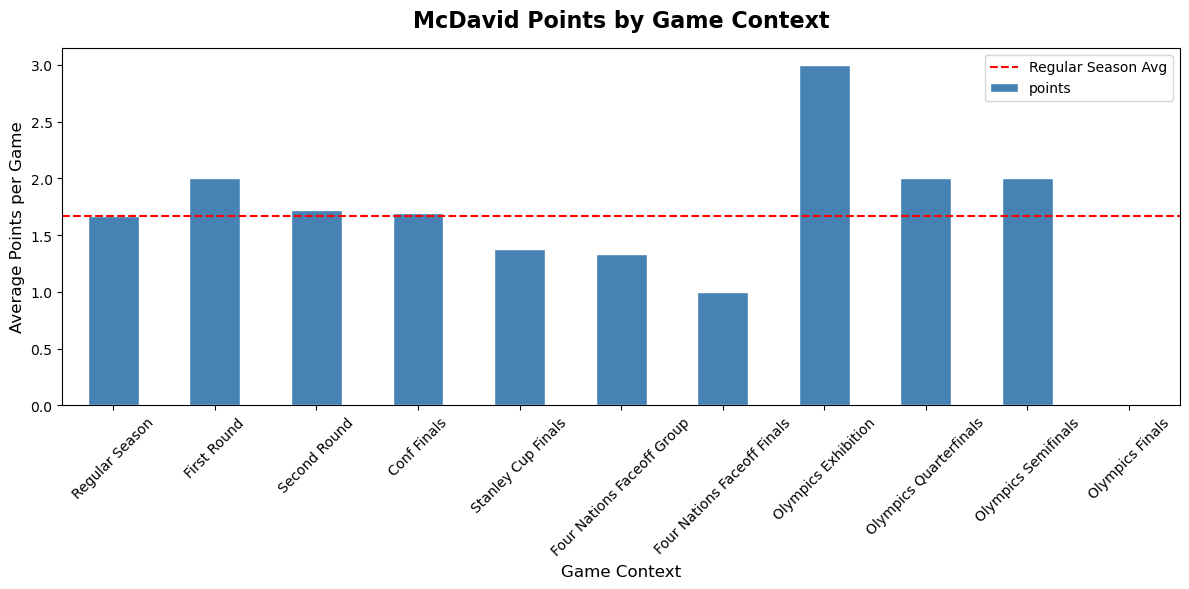

In [22]:
context_order = [
    'regular_season',
    'first_round',
    'second_round',
    'conf_finals',
    'stanley_cup_finals',
    'four_nations_faceoff_group',
    'four_nations_faceoff_finals',
    'olympics_exhibition',
    'olympics_quarterfinals',
    'olympics_semifinals',
    'olympics_finals'
]

context_avg.reindex(context_order)

fig, ax = plt.subplots(figsize=(12, 6))

context_avg.reindex(context_order)['points'].plot(
    kind='bar',
    ax=ax,
    color='steelblue',
    edgecolor='white'
)

ax.set_title('McDavid Points by Game Context', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Game Context', fontsize=12)
ax.set_ylabel('Average Points per Game', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=context_avg.loc['regular_season', 'points'], 
           color='red', linestyle='--', linewidth=1.5, 
           label='Regular Season Avg')
ax.legend()

plt.tight_layout()
ax.set_xticklabels([label.get_text().replace('_', ' ').title() 
                    for label in ax.get_xticklabels()])
plt.show()

### Interpretation
McDavid's average points per game remain at or above his regular 
season baseline through the conference finals, suggesting he does 
not decline in early playoff rounds. The notable drops occur 
specifically in the Stanley Cup Finals and the Olympic gold medal 
game — the two highest stakes games in hockey.

### 1.2 Average Plus/Minus by Game Context

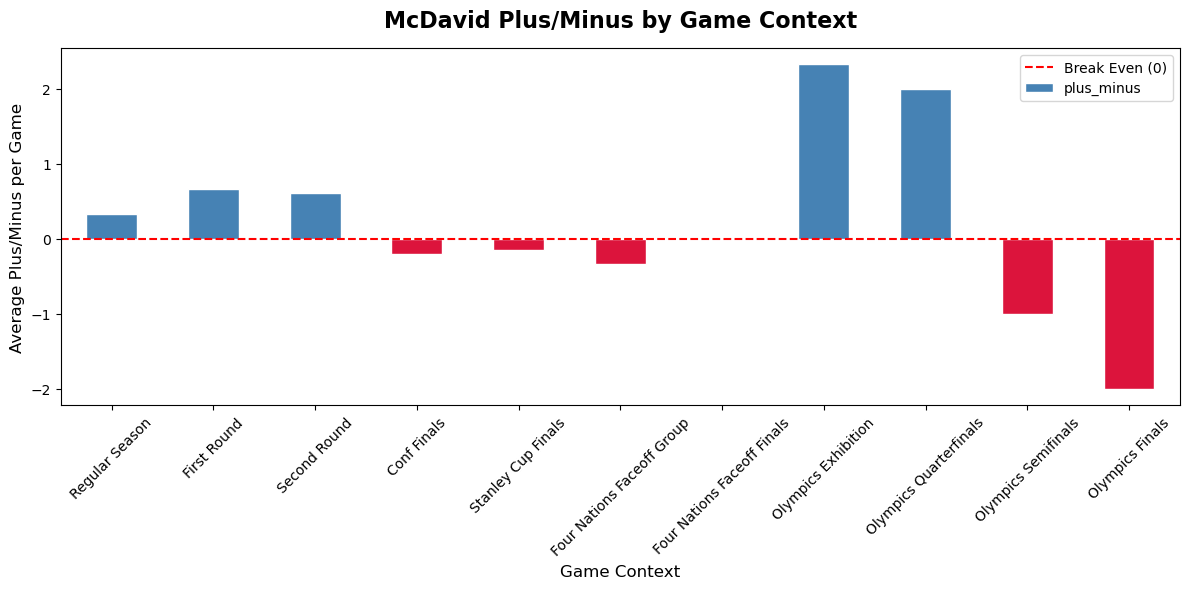

In [34]:
colors = ['steelblue' if val >= 0 else 'crimson' 
          for val in context_avg.reindex(context_order)['plus_minus']]

fig, ax = plt.subplots(figsize=(12, 6))

context_avg.reindex(context_order)['plus_minus'].plot(
    kind='bar',
    ax=ax,
    color=colors,
    edgecolor='white'
)

ax.set_title('McDavid Plus/Minus by Game Context', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Game Context', fontsize=12)
ax.set_ylabel('Average Plus/Minus per Game', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0, 
           color='red', linestyle='--', linewidth=1.5, 
           label='Break Even (0)')
ax.legend()

plt.tight_layout()
ax.set_xticklabels([label.get_text().replace('_', ' ').title() 
                    for label in ax.get_xticklabels()])
plt.show()

### Interpretation
The trend is very similar to the previous graph based on average points per game. McDavid is still consistently performing well in the regular season and early 